# Checkpoint 1 

Neste checkpoint, o objetivo é testar dois modelos para classificação de textos:
1. um baseline de regressão logística;
2. uma Deep Neural Network (DNN).

## Imports

In [13]:
import re
from collections import Counter
import sys
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../models"))

from activation import ReLUActivation, SigmoidActivation
from layers import DenseLayer, DropoutLayer
from losses import BinaryCrossEntropy
from neuralnetwork import NeuralNetwork
from model_pytorch import train_pytorch_model, predict_pytorch

## Dataset

In [14]:
df = pd.read_csv("../data/dataset_final.csv")
df.head()

,Text,source_name,source_code
0,INTEGRAL monitoring of the Galactic Plane is...,human,0
1,Satellite altimetry ice sheet mass balance est...,Anthropic,2
2,The shares shall be repurchased through public...,human,0
3,The study of coherent correlation spectroscopy...,openai,4
4,Circulating tumor cell epithelial-mesenchymal ...,Anthropic,2


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15637 entries, 0 to 15636
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Text         15637 non-null  object
 1   source_name  15637 non-null  object
 2   source_code  15637 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 366.6+ KB


In [16]:
df["source_name"].value_counts()

source_name
human        7650
openai       2435
google       1900
meta         1838
Anthropic    1814
Name: count, dtype: int64

## Análise inicial do dataset

O dataset contém textos classificados por origem.  
As classes disponíveis são:

- human
- openai
- google
- meta
- mistral

Para esta primeira abordagem, vamos converter o problema para classificação binária:
- **human = 0**
- **qualquer modelo LLM = 1**

In [17]:
df["binary_label"] = (df["source_name"] != "human").astype(int)

# 3. Dataset for llm classes
df_llm_only = df[df["source_name"] != "human"].copy()
llm_mapping = {"openai": 0, "google": 1, "meta": 2, "anthropic": 3}
df_llm_only["llm_label"] = df_llm_only["source_name"].map(llm_mapping)

#df["binary_label"].value_counts(normalize=True) * 100 #PERCENTAGEM

In [18]:
print("Binary distribution:")
print(df["binary_label"].value_counts())
print("\nLLMs distribution:")
print(df_llm_only["source_name"].value_counts())

Binary distribution:
binary_label
1    7987
0    7650
Name: count, dtype: int64

LLMs distribution:
source_name
openai       2435
google       1900
meta         1838
Anthropic    1814
Name: count, dtype: int64


## Visualização Gráfica

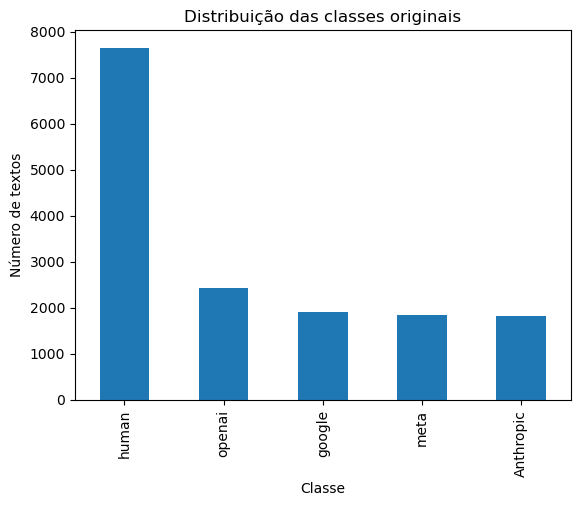

In [19]:
df["source_name"].value_counts().plot(kind="bar")
plt.title("Distribuição das classes originais")
plt.xlabel("Classe")
plt.ylabel("Número de textos")
plt.show()

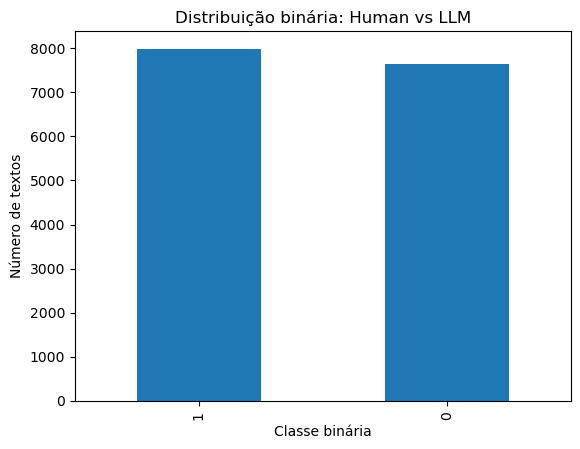

In [20]:
df["binary_label"].value_counts().plot(kind="bar")
plt.title("Distribuição binária: Human vs LLM")
plt.xlabel("Classe binária")
plt.ylabel("Número de textos")
plt.show()

## Pré-Processamento

Os textos são extraídos para uma variável de entrada e os rótulos binários para uma variável alvo. A partir daqui, os dados serão divididos em treino e teste, e posteriormente convertidos em representações numéricas.

Separação estratificada simples, proporção entre as classes no conjunto de treino e no conjunto de teste.

In [21]:
def train_test_split_manual(X, y, test_size=0.2, random_state=42):
    rng = np.random.default_rng(random_state)

    class_0_idx = np.where(y == 0)[0]
    class_1_idx = np.where(y == 1)[0]

    rng.shuffle(class_0_idx)
    rng.shuffle(class_1_idx)

    n0_test = int(len(class_0_idx) * test_size)
    n1_test = int(len(class_1_idx) * test_size)

    test_idx = np.concatenate([class_0_idx[:n0_test], class_1_idx[:n1_test]])
    train_idx = np.concatenate([class_0_idx[n0_test:], class_1_idx[n1_test:]])

    rng.shuffle(train_idx)
    rng.shuffle(test_idx)

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

# Split para o Modelo 1 (Binário - NumPy)
X_train_text, X_test_text, y_train_bin, y_test_bin = train_test_split_manual(
    df["Text"].astype(str).values, df["binary_label"].values, test_size=0.2
)

# Split para o Modelo 2 (Multi-classe - PyTorch)
X_train_llm_text, X_test_llm_text, y_train_llm, y_test_llm = train_test_split_manual(
    df_llm_only["Text"].astype(str).values, df_llm_only["llm_label"].values, test_size=0.2
)

print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))
print("Train size llm", len(X_train_llm_text))
print("Test size llm", len(X_test_llm_text))

Train size: 12510
Test size: 3127
Train size llm 3468
Test size llm 867


1. tokenização e normalização do texto;
2. remoção de stopwords;
3. construção do vocabulário a partir do conjunto de treino;
4. cálculo do IDF para cada termo;
5. vetorização TF-IDF dos textos de treino e teste.

In [22]:
STOPWORDS = {
    "the", "a", "an", "and", "or", "of", "to", "in", "on", "at", "for", "with",
    "is", "are", "was", "were", "be", "been", "being", "this", "that", "these",
    "those", "it", "its", "as", "by", "from", "but", "about", "into", "than",
    "then", "so", "such", "if", "their", "there", "they", "them", "he", "she",
    "you", "your", "we", "our", "i", "my", "me", "his", "her", "what", "which",
    "who", "whom", "can", "could", "should", "would", "do", "does", "did", "have",
    "has", "had", "not", "no", "yes", "will", "just"
}

def tokenize(text):
    text = text.lower()
    tokens = re.findall(r"\b[a-zA-ZÀ-ÿ]{2,}\b", text)
    return [tok for tok in tokens if tok not in STOPWORDS]

def build_vocabulary(texts, max_features=5000):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    most_common = counter.most_common(max_features)
    vocab = {word: idx for idx, (word, _) in enumerate(most_common)}
    return vocab

def compute_idf(tokenized_texts, vocab):
    n_docs = len(tokenized_texts)
    df_counts = np.zeros(len(vocab), dtype=np.float64)

    for tokens in tokenized_texts:
        unique_tokens = set(tok for tok in tokens if tok in vocab)
        for tok in unique_tokens:
            df_counts[vocab[tok]] += 1

    idf = np.log((1 + n_docs) / (1 + df_counts)) + 1
    return idf

def vectorize_tfidf(texts, vocab, idf):
    X = np.zeros((len(texts), len(vocab)), dtype=np.float64)

    for i, text in enumerate(texts):
        tokens = [tok for tok in tokenize(text) if tok in vocab]
        if not tokens:
            continue

        counts = Counter(tokens)
        total_terms = len(tokens)

        for tok, count in counts.items():
            j = vocab[tok]
            tf = count / total_terms
            X[i, j] = tf * idf[j]

    return X

def l2_normalize_rows(X, eps=1e-12):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / (norms + eps)

vocab = build_vocabulary(X_train_text, max_features=5000)

train_tokens = [tokenize(text) for text in X_train_text]
idf = compute_idf(train_tokens, vocab)

X_train = vectorize_tfidf(X_train_text, vocab, idf)
X_test = vectorize_tfidf(X_test_text, vocab, idf)

X_train_llm = vectorize_tfidf(X_train_llm_text, vocab, idf)
X_test_llm = vectorize_tfidf(X_test_llm_text, vocab, idf)

X_train = l2_normalize_rows(X_train)
X_test = l2_normalize_rows(X_test)

X_train_llm = l2_normalize_rows(X_train_llm)
X_test_llm+l2_normalize_rows(X_test_llm)

print("Vocabulary size:", len(vocab))
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_train_llm shape:", X_train_llm.shape)
print("X_test_llm shape:", X_test_llm.shape)

Vocabulary size: 5000
X_train shape: (12510, 5000)
X_test shape: (3127, 5000)
X_train_llm shape: (3468, 5000)
X_test_llm shape: (867, 5000)


In [23]:
# ajuste ao neuralnetwork.py

class SimpleDataset:
    def __init__(self, X, y):
        self.X = X
        self.y = y

train_data = SimpleDataset(X_train, y_train_bin)
test_data = SimpleDataset(X_test, y_test_llm)

In [27]:
input_dim = X_train_llm.shape[1]
model_pytorch = train_pytorch_model(X_train_llm, y_train_llm, input_dim, 4)

A iniciar o treino (4 classes)...
Epochs: [10/50], Perda: 0.2714
Epochs: [20/50], Perda: 0.1139
Epochs: [30/50], Perda: 0.0756
Epochs: [40/50], Perda: 0.0552
Epochs: [50/50], Perda: 0.0464


# Baseline: Regressão Logística

Binary Cross-Entropy como função de perda.

In [28]:
baseline_model = NeuralNetwork(
    epochs=80,
    batch_size=64,
    learning_rate=0.001,
    momentum=0.9,
    verbose=True,
    loss=BinaryCrossEntropy,
    metric=None,
    early_stopping=True,
    early_stopping_patience=8
)

baseline_model.add(DenseLayer(1, input_shape=(X_train.shape[1],), initialization="xavier"))
baseline_model.add(SigmoidActivation())

In [29]:
baseline_model.fit(train_data)

Epoch 1/80 - loss: 0.6939
Epoch 2/80 - loss: 0.6937
Epoch 3/80 - loss: 0.6936
Epoch 4/80 - loss: 0.6934
Epoch 5/80 - loss: 0.6933
Epoch 6/80 - loss: 0.6931
Epoch 7/80 - loss: 0.6930
Epoch 8/80 - loss: 0.6928
Epoch 9/80 - loss: 0.6927
Epoch 10/80 - loss: 0.6926
Epoch 11/80 - loss: 0.6924
Epoch 12/80 - loss: 0.6923
Epoch 13/80 - loss: 0.6921
Epoch 14/80 - loss: 0.6920
Epoch 15/80 - loss: 0.6919
Epoch 16/80 - loss: 0.6917
Epoch 17/80 - loss: 0.6916
Epoch 18/80 - loss: 0.6914
Epoch 19/80 - loss: 0.6913
Epoch 20/80 - loss: 0.6912
Epoch 21/80 - loss: 0.6910
Epoch 22/80 - loss: 0.6909
Epoch 23/80 - loss: 0.6908
Epoch 24/80 - loss: 0.6906
Epoch 25/80 - loss: 0.6905
Epoch 26/80 - loss: 0.6904
Epoch 27/80 - loss: 0.6902
Epoch 28/80 - loss: 0.6901
Epoch 29/80 - loss: 0.6900
Epoch 30/80 - loss: 0.6898
Epoch 31/80 - loss: 0.6897
Epoch 32/80 - loss: 0.6896
Epoch 33/80 - loss: 0.6894
Epoch 34/80 - loss: 0.6893
Epoch 35/80 - loss: 0.6892
Epoch 36/80 - loss: 0.6890
Epoch 37/80 - loss: 0.6889
Epoch 38/8

In [30]:
y_pred_prob_baseline = baseline_model.predict(test_data)
y_pred_baseline = (y_pred_prob_baseline >= 0.5).astype(int).flatten()

In [33]:
def accuracy_score_manual(y_true, y_pred):
    return np.mean(y_true == y_pred)

def confusion_matrix_manual(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[tn, fp],
                     [fn, tp]])

def precision_score_manual(y_true, y_pred):
    cm = confusion_matrix_manual(y_true, y_pred)
    tp = cm[1, 1]
    fp = cm[0, 1]
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall_score_manual(y_true, y_pred):
    cm = confusion_matrix_manual(y_true, y_pred)
    tp = cm[1, 1]
    fn = cm[1, 0]
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def f1_score_manual(y_true, y_pred):
    precision = precision_score_manual(y_true, y_pred)
    recall = recall_score_manual(y_true, y_pred)
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

def classification_report_manual(y_true, y_pred):
    precision_0 = precision_score_manual(1 - y_true, 1 - y_pred)
    recall_0 = recall_score_manual(1 - y_true, 1 - y_pred)
    f1_0 = f1_score_manual(1 - y_true, 1 - y_pred)
    support_0 = np.sum(y_true == 0)

    precision_1 = precision_score_manual(y_true, y_pred)
    recall_1 = recall_score_manual(y_true, y_pred)
    f1_1 = f1_score_manual(y_true, y_pred)
    support_1 = np.sum(y_true == 1)

    print("Classe\tPrecision\tRecall\t\tF1-score\tSupport")
    print(f"human\t{precision_0:.4f}\t\t{recall_0:.4f}\t\t{f1_0:.4f}\t\t{support_0}")
    print(f"LLM\t{precision_1:.4f}\t\t{recall_1:.4f}\t\t{f1_1:.4f}\t\t{support_1}")

baseline_accuracy = accuracy_score_manual(y_test_bin, y_pred_baseline)
baseline_precision = precision_score_manual(y_test_bin, y_pred_baseline)
baseline_recall = recall_score_manual(y_test_bin, y_pred_baseline)
baseline_f1 = f1_score_manual(y_test_bin, y_pred_baseline)

print("Accuracy:", baseline_accuracy)
print("Precision:", baseline_precision)
print("Recall:", baseline_recall)
print("F1-score:", baseline_f1)

Accuracy: 0.6590981771666133
Precision: 0.6009122006841505
Recall: 0.9899812147777082
F1-score: 0.7478713339640493


## DNN(NumPy)

- camada densa intermédia;
- ativação ReLU;
- dropout como técnica de regularização;
- camada de saída com ativação sigmoide.

In [34]:
model = NeuralNetwork(
    epochs=100,
    batch_size=64,
    learning_rate=0.001,
    momentum=0.9,
    verbose=True,
    loss=BinaryCrossEntropy,
    metric=None,
    early_stopping=True,
    early_stopping_patience=10
)

model.add(DenseLayer(64, input_shape=(X_train.shape[1],), l2_lambda=1e-4, initialization="he"))
model.add(ReLUActivation())
model.add(DropoutLayer(0.2))
model.add(DenseLayer(1, l2_lambda=1e-4, initialization="xavier"))
model.add(SigmoidActivation())

In [35]:
model.fit(train_data)

Epoch 1/100 - loss: 0.6928
Epoch 2/100 - loss: 0.6927
Epoch 3/100 - loss: 0.6924
Epoch 4/100 - loss: 0.6924
Epoch 5/100 - loss: 0.6922
Epoch 6/100 - loss: 0.6922
Epoch 7/100 - loss: 0.6920
Epoch 8/100 - loss: 0.6918
Epoch 9/100 - loss: 0.6917
Epoch 10/100 - loss: 0.6916
Epoch 11/100 - loss: 0.6915
Epoch 12/100 - loss: 0.6915
Epoch 13/100 - loss: 0.6913
Epoch 14/100 - loss: 0.6911
Epoch 15/100 - loss: 0.6911
Epoch 16/100 - loss: 0.6910
Epoch 17/100 - loss: 0.6908
Epoch 18/100 - loss: 0.6907
Epoch 19/100 - loss: 0.6905
Epoch 20/100 - loss: 0.6903
Epoch 21/100 - loss: 0.6902
Epoch 22/100 - loss: 0.6901
Epoch 23/100 - loss: 0.6900
Epoch 24/100 - loss: 0.6898
Epoch 25/100 - loss: 0.6899
Epoch 26/100 - loss: 0.6898
Epoch 27/100 - loss: 0.6896
Epoch 28/100 - loss: 0.6894
Epoch 29/100 - loss: 0.6893
Epoch 30/100 - loss: 0.6891
Epoch 31/100 - loss: 0.6890
Epoch 32/100 - loss: 0.6888
Epoch 33/100 - loss: 0.6888
Epoch 34/100 - loss: 0.6886
Epoch 35/100 - loss: 0.6884
Epoch 36/100 - loss: 0.6882
E

In [36]:
y_pred_prob = model.predict(test_data)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

print(y_pred_prob[:10])
print(y_pred[:10])

[[0.50162014]
 [0.47777143]
 [0.49275995]
 [0.50875838]
 [0.53285729]
 [0.52624183]
 [0.51988585]
 [0.50778191]
 [0.51205445]
 [0.50547547]]
[1 0 0 1 1 1 1 1 1 1]


In [38]:
dnn_accuracy = accuracy_score_manual(y_test_bin, y_pred)
dnn_precision = precision_score_manual(y_test_bin, y_pred)
dnn_recall = recall_score_manual(y_test_bin, y_pred)
dnn_f1 = f1_score_manual(y_test_bin, y_pred)

print("Accuracy:", dnn_accuracy)
print("Precision:", dnn_precision)
print("Recall:", dnn_recall)
print("F1-score:", dnn_f1)

print("\nClassification report:")
classification_report_manual(y_test_bin, y_pred)

cm = confusion_matrix_manual(y_test_bin, y_pred)
print("\nConfusion matrix:")
print(cm)

Accuracy: 0.7236968340262232
Precision: 0.653797733948804
Recall: 0.9755792110206637
F1-score: 0.7829145728643216

Classification report:
Classe	Precision	Recall		F1-score	Support
human	0.9476		0.4608		0.6201		1530
LLM	0.6538		0.9756		0.7829		1597

Confusion matrix:
[[ 705  825]
 [  39 1558]]


In [39]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression (NumPy)", "DNN (NumPy)"],
    "Accuracy": [baseline_accuracy, dnn_accuracy],
    "Precision": [baseline_precision, dnn_precision],
    "Recall": [baseline_recall, dnn_recall],
    "F1-score": [baseline_f1, dnn_f1]
})
comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression (NumPy),0.659098,0.600912,0.989981,0.747871
1,DNN (NumPy),0.723697,0.653798,0.975579,0.782915


O DNN atingiu o melhor desempenho global, com um F1-score de 0.77, em comparação com o 0.71 da baseline de regressão logistica.

Ambos os modelos atingiram um recall alto na deteção de texto gerado por IA. O DNN aumentou a precision, fruto de um melhor equilíbrio entre falsos positivos e falsos negativos.

## Curvas de Treino

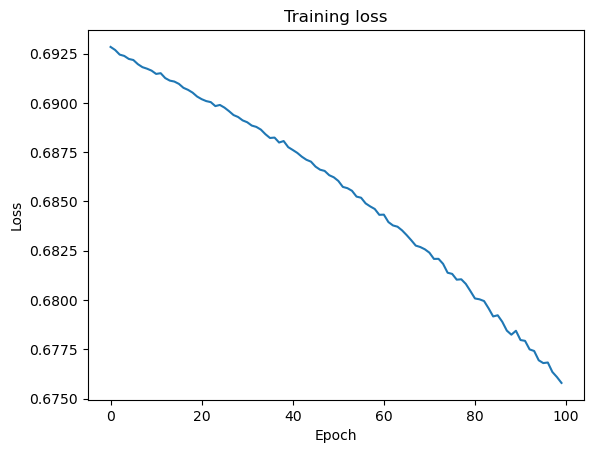

In [40]:
plt.plot(model.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()